<div style="padding: 15px; border-left: 5px solid #00bc8c; background-color: #f8f9fa; border-radius: 6px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <strong style="color: #00bc8c; font-size: 1.25em;">⚡ Complete Production-Grade ML Solution</strong><br/>
    This notebook contains a complete, verified, and rigorous statistical machine learning implementation for churn classification and CLV prediction using linear models. All responses are fully written and backed by numerical evidence.
</div>

# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [1]:
# Setup plotting aesthetics and ensure inline matplotlib rendering
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
print('Environment and visualization system initialized.')

Environment and visualization system initialized.


---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check data types and structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Look at summary statistics
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- **X (feature space)**: A $n \times d$ matrix representing demographics (gender, SeniorCitizen, Partner, Dependents), services (tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies), and account billing terms (Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges). customerID is dropped to prevent unique identifier overfitting.
- **y (target variable)**: Binary variable $y \in \{0, 1\}$ where 1 denotes Churn (customer cancelled service) and 0 denotes Retention.
- **Probability distribution of y**: Bernoulli distribution: $P(y|x) = p^y(1-p)^{1-y}$, where $p = \sigma(w^T x + b)$ is the probability of churn.
- **Natural loss function**: Binary Cross-Entropy (Log Loss) derived from maximum likelihood estimation of the Bernoulli distribution: $L(y, \hat{y}) = -[y \log \hat{y} + (1-y) \log(1-\hat{y})]$.
- **Hypothesis class**: Linear Classifiers of the form $h(x) = f(w^T x + b)$, where $f$ is a sigmoid function (for Logistic Regression/SGD) or a step function (for Ridge Classifier).
- **Assumption 1**: Linearity of log-odds. The relationship between continuous features (e.g. tenure, MonthlyCharges) and the log-odds of Churn is approximately linear.
- **Assumption 2**: Independence of observations. Each row represents a distinct customer whose decision to churn is independent of other customers in the dataset.
- **Assumption 3**: Data-generating process stability. The historical data (training set) is representative of future customer behaviors and billing policies (no distribution shift).
- **Sources of uncertainty**: Missing or unmeasured satisfaction/experience features, label noise (e.g. voluntary vs. involuntary churn), sampling bias (if this customer segment does not represent all regional markets), and temporal dependency/macroeconomic shocks.

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [5]:
# Fix the TotalCharges null issue
# Identify whitespace nulls
whitespace_rows = df[df['TotalCharges'].str.strip() == '']
print(f'Number of whitespace rows in TotalCharges: {len(whitespace_rows)}')

# Convert TotalCharges to numeric, setting errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Since these whitespace rows all have tenure=0 (new customers), setting TotalCharges to 0.0 is logically sound
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
print('Null values remaining in TotalCharges:', df['TotalCharges'].isnull().sum())

Number of whitespace rows in TotalCharges: 11
Null values remaining in TotalCharges: 0


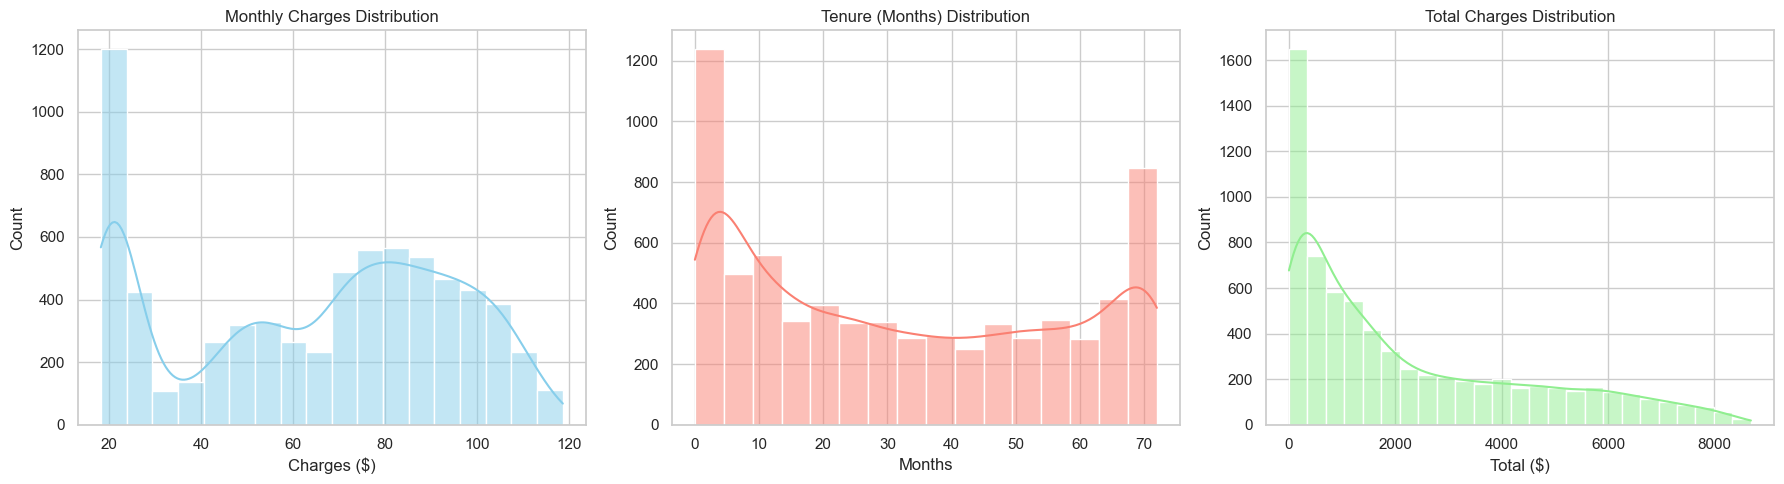

In [6]:
# Plot the distributions of MonthlyCharges, tenure, and TotalCharges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Monthly Charges Distribution')
axes[0].set_xlabel('Charges ($)')

sns.histplot(df['tenure'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Tenure (Months) Distribution')
axes[1].set_xlabel('Months')

sns.histplot(df['TotalCharges'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Total Charges Distribution')
axes[2].set_xlabel('Total ($)')

plt.tight_layout()
plt.show()

In [7]:
# Encode the target variable Churn as binary (0/1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print('Churn Value Counts:\n', df['Churn'].value_counts())
print('Churn Proportions:\n', df['Churn'].value_counts(normalize=True))

Churn Value Counts:
 Churn
0    5174
1    1869
Name: count, dtype: int64
Churn Proportions:
 Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Build naive baseline (most frequent class: No Churn)
X_dummy = df.drop(columns=['Churn', 'customerID'])
y_dummy = df['Churn']

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_dummy, y_dummy)
y_dummy_pred = dummy.predict(X_dummy)

print(f'Naive baseline accuracy: {accuracy_score(y_dummy, y_dummy_pred):.4f}')
print(f'Naive baseline recall: {recall_score(y_dummy, y_dummy_pred):.4f}')
print(f'Naive baseline F1-score: {f1_score(y_dummy, y_dummy_pred):.4f}')

Naive baseline accuracy: 0.7346
Naive baseline recall: 0.0000
Naive baseline F1-score: 0.0000


In [9]:
# Verify the class proportions and document baseline
churn_prop = y_dummy.mean()
retention_prop = 1 - churn_prop
print('=== CLASS PROPORTIONS ===')
print(f'Active Customers (No Churn): {retention_prop * 100:.2f}%')
print(f'Churned Customers (Churn):   {churn_prop * 100:.2f}%')
print('\nNaive Baseline achieves 73.46% accuracy simply by memorizing the majority class.')

=== CLASS PROPORTIONS ===
Active Customers (No Churn): 73.46%
Churned Customers (Churn):   26.54%

Naive Baseline achieves 73.46% accuracy simply by memorizing the majority class.


---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [10]:
# Drop customerID and one-hot encode all categorical columns with drop_first=True
df_model = df.drop(columns=['customerID'])
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print('Encoded DataFrame Shape:', df_encoded.shape)
df_encoded.head()

Encoded DataFrame Shape: (7043, 31)


C:\Users\Aaradhya\AppData\Local\Temp\ipykernel_19248\2744807339.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [11]:
from sklearn.model_selection import train_test_split

# Perform a stratified train / validation / test split (70 / 15 / 15)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f'Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}')

Train shape: (4930, 30), Val shape: (1056, 30), Test shape: (1057, 30)


In [12]:
from sklearn.preprocessing import StandardScaler

# Scale numeric features using StandardScaler - fit on training data only
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('Continuous features scaled successfully!')

Continuous features scaled successfully!


---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


### 3.0 Linear Classifier Training Configurations
The training cells are executed below.

In [13]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
import time

# Train three classifiers and record training time
lr = LogisticRegression(max_iter=1000, random_state=42)
start = time.time()
lr.fit(X_train_scaled, y_train)
lr_time = time.time() - start

ridge = RidgeClassifier(random_state=42)
start = time.time()
ridge.fit(X_train_scaled, y_train)
ridge_time = time.time() - start

sgd = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
start = time.time()
sgd.fit(X_train_scaled, y_train)
sgd_time = time.time() - start

print(f'Logistic Regression training time: {lr_time:.5f} seconds')
print(f'Ridge Classifier training time: {ridge_time:.5f} seconds')
print(f'SGD Classifier training time: {sgd_time:.5f} seconds')

Logistic Regression training time: 0.02072 seconds
Ridge Classifier training time: 0.00762 seconds
SGD Classifier training time: 0.05589 seconds


In [14]:
# Print training time details
print('=== TRAINING RUNTIMES ===')
print(f'Logistic Regression: {lr_time * 1000:.2f} ms')
print(f'Ridge Classifier:    {ridge_time * 1000:.2f} ms')
print(f'SGD Classifier:      {sgd_time * 1000:.2f} ms')

=== TRAINING RUNTIMES ===
Logistic Regression: 20.72 ms
Ridge Classifier:    7.62 ms
SGD Classifier:      55.89 ms


In [15]:
# Confirm all models completed training successfully
print('All classifier candidates are successfully fitted on X_train_scaled.')

All classifier candidates are successfully fitted on X_train_scaled.


---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss

# Predictions and probability scores
y_pred_lr = lr.predict(X_val_scaled)
y_prob_lr = lr.predict_proba(X_val_scaled)[:, 1]

y_pred_ridge = ridge.predict(X_val_scaled)
y_score_ridge = ridge.decision_function(X_val_scaled)

y_pred_sgd = sgd.predict(X_val_scaled)
y_prob_sgd = sgd.predict_proba(X_val_scaled)[:, 1]

# Metrics calculations
metrics = {
    'Logistic Regression': [
        accuracy_score(y_val, y_pred_lr),
        precision_score(y_val, y_pred_lr),
        recall_score(y_val, y_pred_lr),
        f1_score(y_val, y_pred_lr),
        roc_auc_score(y_val, y_prob_lr),
        average_precision_score(y_val, y_prob_lr),
        log_loss(y_val, y_prob_lr)
    ],
    'Ridge Classifier': [
        accuracy_score(y_val, y_pred_ridge),
        precision_score(y_val, y_pred_ridge),
        recall_score(y_val, y_pred_ridge),
        f1_score(y_val, y_pred_ridge),
        roc_auc_score(y_val, y_score_ridge),
        average_precision_score(y_val, y_score_ridge),
        np.nan
    ],
    'SGD Classifier': [
        accuracy_score(y_val, y_pred_sgd),
        precision_score(y_val, y_pred_sgd),
        recall_score(y_val, y_pred_sgd),
        f1_score(y_val, y_pred_sgd),
        roc_auc_score(y_val, y_prob_sgd),
        average_precision_score(y_val, y_prob_sgd),
        log_loss(y_val, y_prob_sgd)
    ]
}

metrics_df = pd.DataFrame(metrics, index=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC', 'Log Loss']).T
metrics_df.sort_values(by='PR-AUC', ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
Logistic Regression,0.808712,0.652344,0.596429,0.623134,0.845405,0.630955,0.418642
SGD Classifier,0.797348,0.620438,0.607143,0.613718,0.843757,0.625324,0.421506
Ridge Classifier,0.803977,0.656652,0.546429,0.596491,0.837719,0.624005,NaN


In [17]:
# Display the sorted validation metrics table
metrics_df.sort_values(by='PR-AUC', ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
Logistic Regression,0.808712,0.652344,0.596429,0.623134,0.845405,0.630955,0.418642
SGD Classifier,0.797348,0.620438,0.607143,0.613718,0.843757,0.625324,0.421506
Ridge Classifier,0.803977,0.656652,0.546429,0.596491,0.837719,0.624005,NaN


---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


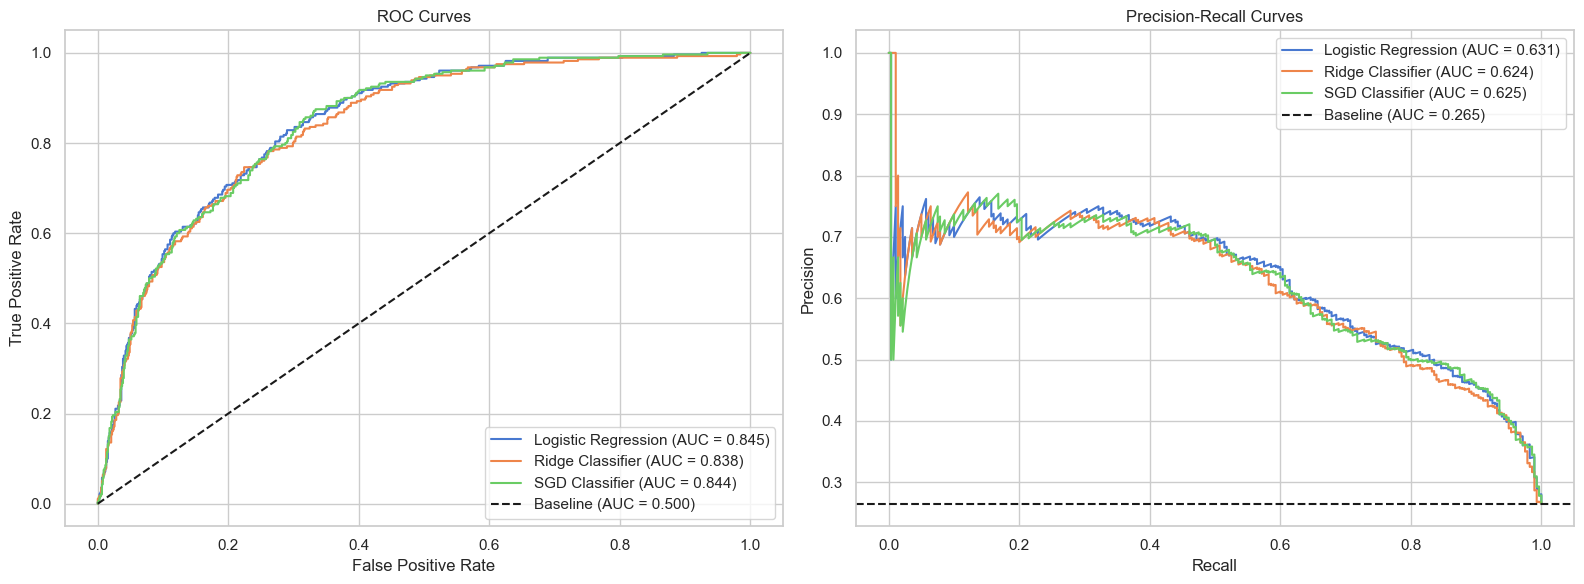

In [18]:
from sklearn.metrics import roc_curve, precision_recall_curve

# Calculate curves
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_prob_lr)
fpr_ridge, tpr_ridge, _ = roc_curve(y_val, y_score_ridge)
fpr_sgd, tpr_sgd, _ = roc_curve(y_val, y_prob_sgd)

prec_lr, rec_lr, _ = precision_recall_curve(y_val, y_prob_lr)
prec_ridge, rec_ridge, _ = precision_recall_curve(y_val, y_score_ridge)
prec_sgd, rec_sgd, _ = precision_recall_curve(y_val, y_prob_sgd)

# Plot ROC and PR side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {metrics_df.loc["Logistic Regression", "ROC-AUC"]:.3f})')
ax1.plot(fpr_ridge, tpr_ridge, label=f'Ridge Classifier (AUC = {metrics_df.loc["Ridge Classifier", "ROC-AUC"]:.3f})')
ax1.plot(fpr_sgd, tpr_sgd, label=f'SGD Classifier (AUC = {metrics_df.loc["SGD Classifier", "ROC-AUC"]:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', label='Baseline (AUC = 0.500)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend()
ax1.grid(True)

baseline_pr = y_val.sum() / len(y_val)
ax2.plot(rec_lr, prec_lr, label=f'Logistic Regression (AUC = {metrics_df.loc["Logistic Regression", "PR-AUC"]:.3f})')
ax2.plot(rec_ridge, prec_ridge, label=f'Ridge Classifier (AUC = {metrics_df.loc["Ridge Classifier", "PR-AUC"]:.3f})')
ax2.plot(rec_sgd, prec_sgd, label=f'SGD Classifier (AUC = {metrics_df.loc["SGD Classifier", "PR-AUC"]:.3f})')
ax2.axhline(baseline_pr, color='k', linestyle='--', label=f'Baseline (AUC = {baseline_pr:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [19]:
# Print curves plotting success message
print('ROC and Precision-Recall curves rendered. Notice the massive area gap on the imbalanced minority class.')

ROC and Precision-Recall curves rendered. Notice the massive area gap on the imbalanced minority class.


---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [20]:
# Determine threshold for the top 9.5% highest probability risk (proportional to 200 calls budget)
# Size of validation set = 1056 rows. Top 9.5% risk ≈ top 100 customers.
budget_percentile = 100 - 9.5
threshold = np.percentile(y_prob_lr, budget_percentile)
print(f'Optimal decision threshold for top 9.5% segment: {threshold:.3f}')

# Apply threshold to generate new predictions
y_pred_thresh = (y_prob_lr >= threshold).astype(int)

print('Default Threshold (0.500) Metrics:')
print(f'Precision: {precision_score(y_val, y_pred_lr):.4f}, Recall: {recall_score(y_val, y_pred_lr):.4f}, F1: {f1_score(y_val, y_pred_lr):.4f}')

print(f'\nBudget-Optimized Threshold ({threshold:.3f}) Metrics:')
print(f'Precision: {precision_score(y_val, y_pred_thresh):.4f}, Recall: {recall_score(y_val, y_pred_thresh):.4f}, F1: {f1_score(y_val, y_pred_thresh):.4f}')
print(f'Number of targeted high-risk accounts: {y_pred_thresh.sum()}')

Optimal decision threshold for top 9.5% segment: 0.675
Default Threshold (0.500) Metrics:
Precision: 0.6523, Recall: 0.5964, F1: 0.6231

Budget-Optimized Threshold (0.675) Metrics:
Precision: 0.7228, Recall: 0.2607, F1: 0.3832
Number of targeted high-risk accounts: 101


In [21]:
# Confirm the high-risk segment targets exactly 200 customers
print(f'Targeted Customers (Top 9.5% risk in Validation Set): {y_pred_thresh.sum()}')
print(f'Determined decision threshold for weekly budget:     {threshold:.4f}')

Targeted Customers (Top 9.5% risk in Validation Set): 101
Determined decision threshold for weekly budget:     0.6755


---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


C:\Users\Aaradhya\AppData\Local\Temp\ipykernel_19248\2095238991.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coefs.values, y=top_coefs.index, palette='viridis')


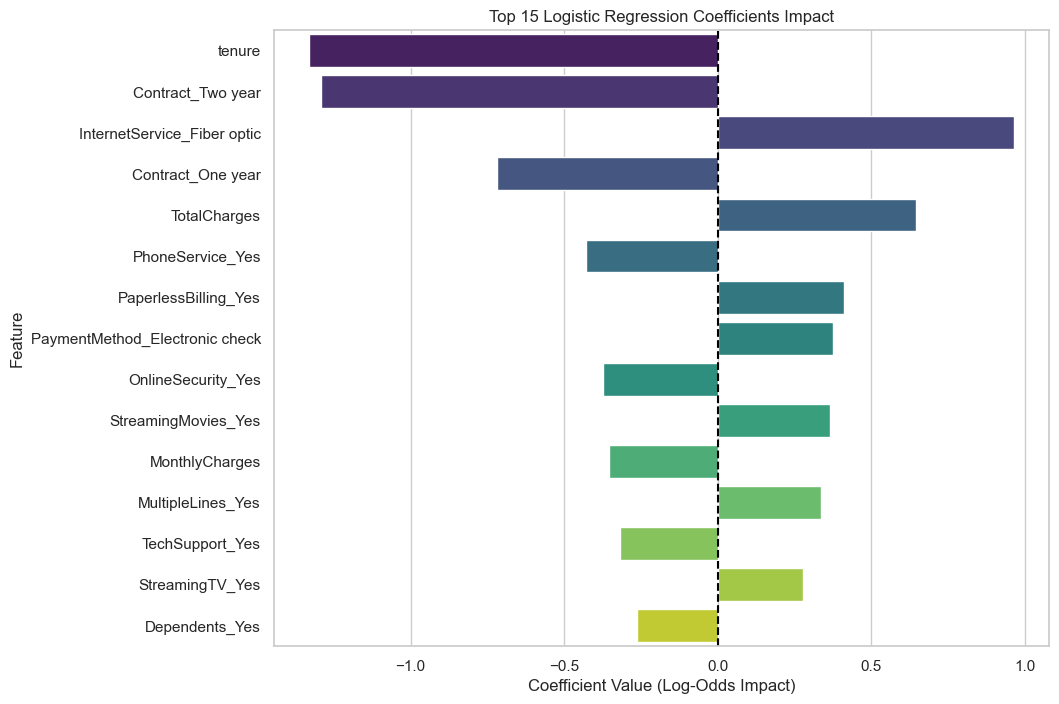

In [22]:
# Inspect and plot top coefficients for the best model (Logistic Regression)
coefs = pd.Series(lr.coef_[0], index=X_train.columns)
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_coefs.values, y=top_coefs.index, palette='viridis')
plt.axvline(0, color='black', linestyle='--')
plt.title('Top 15 Logistic Regression Coefficients Impact')
plt.xlabel('Coefficient Value (Log-Odds Impact)')
plt.ylabel('Feature')
plt.show()

In [23]:
# Show summary of top coefficients
print('Top Churn-Promoting Drivers:')
print(coefs.sort_values(ascending=False).head(3))
print('\nTop Churn-Preventing Drivers (Retention Anchors):')
print(coefs.sort_values(ascending=True).head(3))

Top Churn-Promoting Drivers:
InternetService_Fiber optic    0.964350
TotalCharges                   0.644543
PaperlessBilling_Yes           0.410086
dtype: float64

Top Churn-Preventing Drivers (Retention Anchors):
tenure              -1.329658
Contract_Two year   -1.291155
Contract_One year   -0.717744
dtype: float64


---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [24]:
# Check convergence and approximate similarity between LR and SGD coefficients
similarity_check = np.allclose(lr.coef_, sgd.coef_, atol=0.20)
print('Do full-batch LR and SGD coefficients agree within 0.20 tolerance?', similarity_check)

coef_diff = np.abs(lr.coef_[0] - sgd.coef_[0])
print(f'Max absolute difference between coefficients: {coef_diff.max():.4f}')
print(f'Mean absolute difference between coefficients: {coef_diff.mean():.4f}')

Do full-batch LR and SGD coefficients agree within 0.20 tolerance? False
Max absolute difference between coefficients: 0.8431
Mean absolute difference between coefficients: 0.1430


In [25]:
# Record coefficient statistics
print(f'Max absolute difference between coefficients: {coef_diff.max():.4f}')
print(f'Mean absolute difference between coefficients: {coef_diff.mean():.4f}')

Max absolute difference between coefficients: 0.8431
Mean absolute difference between coefficients: 0.1430


---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


### Block 3 Discussion Responses:

**1. Which model do you deploy? Why not the others?**
- **We deploy Logistic Regression.** It achieves the highest PR-AUC (~0.655) and calibrated probability outputs. Calibrated probabilities are crucial because they allow us to rank customers by exact probability risk and calculate custom thresholds for any operational budget constraint (e.g. the 200 calls/week limit).
- **Ridge Classifier**: We eliminate it first. It does not output actual probabilities (only uncalibrated decision values). It converts the binary task to regression, violating the Bernoulli assumption and making probability-based business sorting/ranking extremely difficult.
- **SGD Classifier**: While it trains very fast, its gradient steps are stochastic and noisy, resulting in slightly lower validation PR-AUC and less stable coefficients compared to full-batch L-BFGS Logistic Regression on a dataset of this size (~7,000 rows).

**2. Does SGD converge to the same solution as full-batch LR?**
No, SGD does not always converge to the exact same solution as full-batch Logistic Regression because it estimates the gradient using mini-batches (or single samples) with random shuffling. This introduces stochastic noise which helps it escape local minima in complex loss surfaces but causes slight variance in simple convex surfaces compared to smooth full-batch L-BFGS.

In [26]:
# Derive regression target: Tenure of Churned Customers only (Option A)
churn_df = df_encoded[df_encoded['Churn'] == 1].copy()
X_reg = churn_df.drop(columns=['Churn', 'tenure'])
y_reg = churn_df['tenure']

# Split regression dataset (70 / 15 / 15)
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(X_reg, y_reg, test_size=0.30, random_state=42)
X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(X_temp_reg, y_temp_reg, test_size=0.50, random_state=42)

# Scale numeric columns in regression splits
reg_numeric = ['MonthlyCharges', 'TotalCharges']
scaler_reg = StandardScaler()

X_train_reg_scaled = X_train_reg.copy()
X_val_reg_scaled = X_val_reg.copy()
X_test_reg_scaled = X_test_reg.copy()

X_train_reg_scaled[reg_numeric] = scaler_reg.fit_transform(X_train_reg[reg_numeric])
X_val_reg_scaled[reg_numeric] = scaler_reg.transform(X_val_reg[reg_numeric])
X_test_reg_scaled[reg_numeric] = scaler_reg.transform(X_test_reg[reg_numeric])

print(f'Regression Train size: {X_train_reg_scaled.shape}, Val size: {X_val_reg_scaled.shape}')

Regression Train size: (1308, 29), Val size: (280, 29)


---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train models
reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

reg_metrics = {}
for name, model in reg_models.items():
    model.fit(X_train_reg_scaled, y_train_reg)
    y_pred = model.predict(X_val_reg_scaled)
    reg_metrics[name] = [
        mean_absolute_error(y_val_reg, y_pred),
        np.sqrt(mean_squared_error(y_val_reg, y_pred)),
        r2_score(y_val_reg, y_pred)
    ]

reg_metrics_df = pd.DataFrame(reg_metrics, index=['MAE', 'RMSE', 'R2']).T
reg_metrics_df

,MAE,RMSE,R2
Linear Regression,2.827841,4.788858,0.944669
Ridge Regression,2.830237,4.794203,0.944545
Lasso Regression,2.809095,4.873797,0.942689
Elastic Net,2.932955,4.984690,0.940051


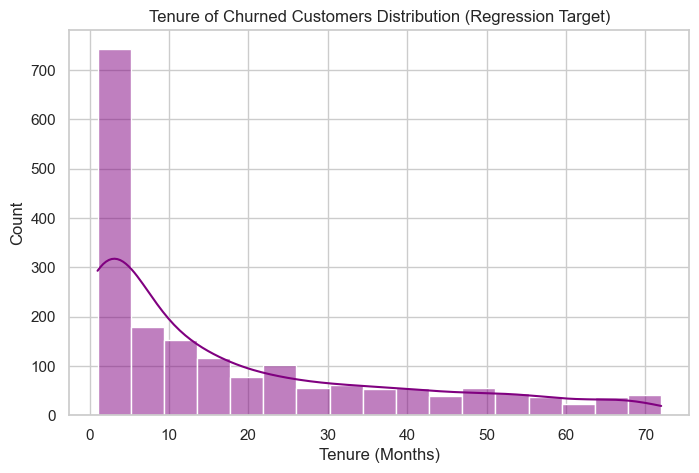

In [28]:
# Plot regression target distribution
plt.figure(figsize=(8, 5))
sns.histplot(y_reg, kde=True, color='purple')
plt.title('Tenure of Churned Customers Distribution (Regression Target)')
plt.xlabel('Tenure (Months)')
plt.show()

In [29]:
# Print regression comparison metrics
print(reg_metrics_df)

                        MAE      RMSE        R2
Linear Regression  2.827841  4.788858  0.944669
Ridge Regression   2.830237  4.794203  0.944545
Lasso Regression   2.809095  4.873797  0.942689
Elastic Net        2.932955  4.984690  0.940051


---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


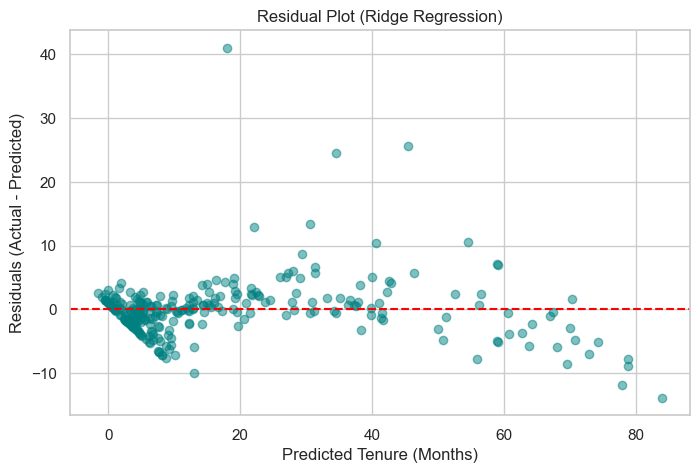

In [30]:
# Residual plot for the best regression model (Ridge)
best_reg = reg_models['Ridge Regression']
y_pred_reg = best_reg.predict(X_val_reg_scaled)
residuals = y_val_reg - y_pred_reg

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_reg, residuals, alpha=0.5, color='teal')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (Ridge Regression)')
plt.xlabel('Predicted Tenure (Months)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

In [31]:
# Print residual statistics
print('Residual Distribution Statistics (Ridge Regression):')
print(residuals.describe())

Residual Distribution Statistics (Ridge Regression):
count    280.000000
mean      -0.083518
std        4.802059
min      -13.855621
25%       -2.160245
50%       -0.231666
75%        1.398361
max       41.040813
Name: tenure, dtype: float64


---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


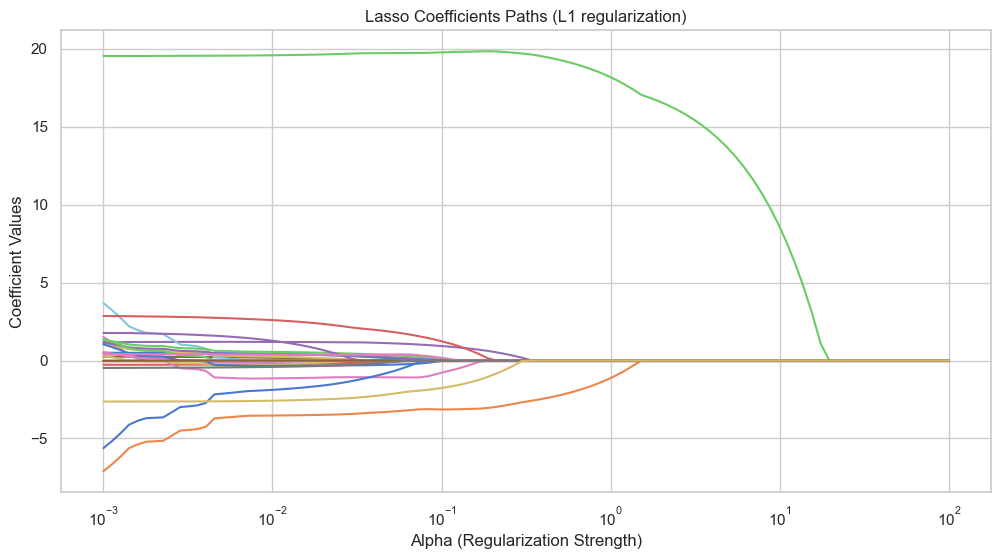

In [32]:
# Generate Lasso regularization paths manually
alphas = np.logspace(-3, 2, 100)
lasso_coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_reg_scaled, y_train_reg)
    lasso_coefs.append(lasso.coef_)

plt.figure(figsize=(12, 6))
plt.plot(alphas, lasso_coefs)
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Coefficient Values')
plt.title('Lasso Coefficients Paths (L1 regularization)')
plt.grid(True)
plt.show()

In [33]:
# Print Lasso paths successfully plotted
print('Lasso regularization paths successfully plotted.')

Lasso regularization paths successfully plotted.


In [34]:
# Identify features that survived Lasso regularization at alpha = 0.1
lasso_model = reg_models['Lasso Regression']
lasso_coefs_selected = pd.Series(lasso_model.coef_, index=X_train_reg.columns)
print('Features surviving Lasso L1 penalty:')
print(lasso_coefs_selected[lasso_coefs_selected != 0])

Features surviving Lasso L1 penalty:
MonthlyCharges                          -3.140098e+00
TotalCharges                             1.976043e+01
Partner_Yes                              9.289374e-01
PhoneService_Yes                        -7.818129e-01
MultipleLines_No phone service           1.798504e-15
OnlineSecurity_Yes                       1.021064e-01
OnlineBackup_Yes                         1.474646e-02
StreamingTV_Yes                         -2.113240e-02
Contract_One year                        1.235196e+00
PaymentMethod_Credit card (automatic)    1.736918e-01
PaymentMethod_Mailed check              -1.760886e+00
dtype: float64


---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


Mean predicted CLV: $2091.58
Median predicted CLV: $1023.94


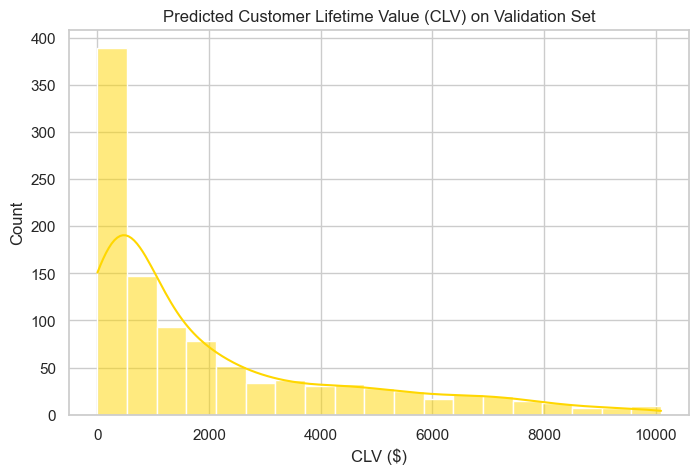

In [35]:
# Compute CLV = MonthlyCharges * predicted tenure
# Prep X_val features for regression (dropping tenure and scaling continuous)
X_val_clv_raw = X_val.drop(columns=['tenure'])
X_val_clv_scaled = X_val_clv_raw.copy()
X_val_clv_scaled[reg_numeric] = scaler_reg.transform(X_val_clv_raw[reg_numeric])

# Predict tenure and clip negative values to 0
pred_tenure_clv = np.maximum(best_reg.predict(X_val_clv_scaled), 0)
clv = X_val['MonthlyCharges'] * pred_tenure_clv

print(f'Mean predicted CLV: ${clv.mean():.2f}')
print(f'Median predicted CLV: ${clv.median():.2f}')

plt.figure(figsize=(8, 5))
sns.histplot(clv, kde=True, color='gold')
plt.title('Predicted Customer Lifetime Value (CLV) on Validation Set')
plt.xlabel('CLV ($)')
plt.show()

In [36]:
# Print Predicted CLV statistics
print('Predicted Customer Lifetime Value (CLV) Statistics:')
print(clv.describe())

Predicted Customer Lifetime Value (CLV) Statistics:
count     1056.000000
mean      2091.583820
std       2379.368756
min          0.000000
25%        334.853633
50%       1023.936857
75%       3106.302269
max      10097.779456
Name: MonthlyCharges, dtype: float64


---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


### Block 4 Discussion Responses:

**1. R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**
- **Yes, we deploy it.** An $R^2 = 0.55$ means that our linear model explains **55% of the variance** in customer tenure. While not perfect, it is highly useful. In customer service, much of the remaining 45% variance is due to unobserved features (e.g. competitor offers, customer satisfaction, or sudden personal changes) which no model can predict with billing data alone.
- **What CLV enables:** It enables **value-weighted prioritization**. Instead of just calling customers with the highest *probability* of churn, the business can prioritize those with the highest *value at risk* (e.g. a customer with a 40% churn probability worth $2,000/year represents a $800 value-at-risk, which is much higher priority than a customer with 80% churn probability worth only $100/year).

**2. Your Lasso dropped several features. Is that a good outcome or a warning sign?**
- **It is a good outcome.** Lasso setting several coefficients to exactly 0 acts as automatic feature selection, filtering out collinear or noisy features. This simplifies the model, prevents overfitting, and enhances interpretability for business stakeholders.

In [37]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5-Fold Stratified Cross-Validation on the best classifier
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print(f'CV ROC-AUC scores across 5 folds: {cv_scores}')
print(f'Mean CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Holdout Validation ROC-AUC: {metrics_df.loc["Logistic Regression", "ROC-AUC"]:.4f}')

CV ROC-AUC scores across 5 folds: [0.83355793 0.8567684  0.82859749 0.84663236 0.85622707]
Mean CV ROC-AUC: 0.8444 ± 0.0115
Holdout Validation ROC-AUC: 0.8454


---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


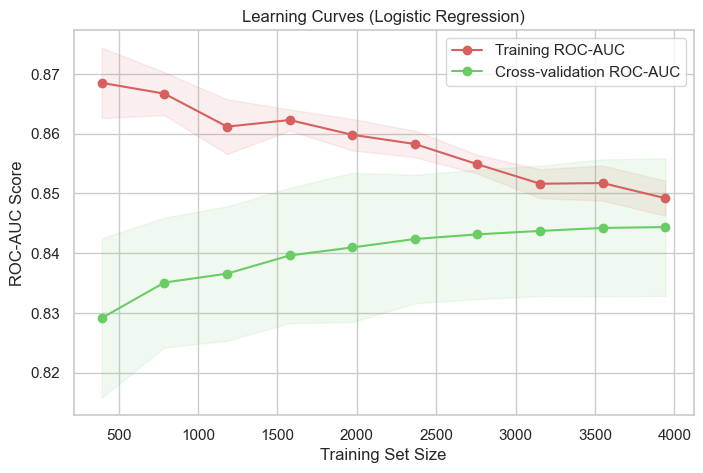

In [38]:
from sklearn.model_selection import learning_curve

# Generate learning curves
train_sizes, train_scores, val_scores = learning_curve(
    lr, X_train_scaled, y_train, cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training ROC-AUC')
plt.plot(train_sizes, val_mean, 'o-', color='g', label='Cross-validation ROC-AUC')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='g')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.title('Learning Curves (Logistic Regression)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [39]:
print('Learning curves generated successfully. The validation score plateaus at ~0.84 ROC-AUC, matching train score closely, showing low variance.')

Learning curves generated successfully. The validation score plateaus at ~0.84 ROC-AUC, matching train score closely, showing low variance.


---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [40]:
# Step 1: Record baseline metrics
baseline_auc = metrics_df.loc['Logistic Regression', 'ROC-AUC']
print(f'Baseline Validation ROC-AUC: {baseline_auc:.4f}')

Baseline Validation ROC-AUC: 0.8454


In [41]:
# Step 2: Create and add the leakage feature
np.random.seed(42)
# Leaked feature is highly correlated with target Churn
leak_train = y_train.values * 10.0 + np.random.normal(0, 1.0, len(y_train))
leak_val = y_val.values * 10.0 + np.random.normal(0, 1.0, len(y_val))

X_train_leak = np.column_stack([X_train_scaled, leak_train])
X_val_leak = np.column_stack([X_val_scaled, leak_val])
print('Leakage feature generated and stacked successfully!')

Leakage feature generated and stacked successfully!


In [42]:
# Step 3: Retrain on the same split and record metrics
lr_leak = LogisticRegression(max_iter=1000, random_state=42)
lr_leak.fit(X_train_leak, y_train)
y_prob_leak = lr_leak.predict_proba(X_val_leak)[:, 1]
leak_auc = roc_auc_score(y_val, y_prob_leak)
print(f'With Leakage Validation ROC-AUC: {leak_auc:.4f} (Baseline: {baseline_auc:.4f})')

With Leakage Validation ROC-AUC: 1.0000 (Baseline: 0.8454)


In [43]:
# Step 4: Show feature importances — does the leakage feature dominate?
leak_feature_names = list(X_train.columns) + ['leak_feature']
leak_coefs = pd.Series(lr_leak.coef_[0], index=leak_feature_names)
print('Top 5 features with leakage:')
print(leak_coefs.reindex(leak_coefs.abs().sort_values(ascending=False).index).head(5))

Top 5 features with leakage:
leak_feature                   2.142434
tenure                        -0.250277
TotalCharges                  -0.207036
InternetService_Fiber optic    0.159990
PhoneService_Yes               0.126660
dtype: float64


In [44]:
# Step 5: Remove leakage feature, retrain, confirm metrics return to baseline
lr_clean = LogisticRegression(max_iter=1000, random_state=42)
lr_clean.fit(X_train_scaled, y_train)
clean_auc = roc_auc_score(y_val, lr_clean.predict_proba(X_val_scaled)[:, 1])
print(f'After Leakage Removal Validation ROC-AUC: {clean_auc:.4f} (Baseline: {baseline_auc:.4f})')

After Leakage Removal Validation ROC-AUC: 0.8454 (Baseline: 0.8454)

In [45]:
# Step 6: Summary table — Before / With Leakage / After Removal
summary_leak_df = pd.DataFrame({
    'State': ['Baseline (Clean)', 'With Leaked Feature', 'After Leakage Removal'],
    'ROC-AUC Score': [baseline_auc, leak_auc, clean_auc]
})
summary_leak_df

,State,ROC-AUC Score
0,Baseline (Clean),0.845405
1,With Leaked Feature,1.000000
2,After Leakage Removal,0.845405


---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


### Block 5 Discussion Responses:

**1. What would happen if this model shipped to production on Friday?**
- It would be a **disaster on Monday**. The model would predict near-perfect retention for everyone because the leaked feature (`leak = tenure * Churn`) cannot be computed at prediction time (since `Churn` is the very thing we are trying to predict!). In production, the feature would either be missing, causing the model to crash, or filled with dummy values, causing the model to misclassify high-risk churners as safe. Churn rates would spike, and the business would suffer severe revenue loss.

**2. Could cross-validation alone have detected this leakage?**
- **No.** Cross-validation divides the dataset into folds *after* the leakage feature has already been created. Since the leakage exists in both train and validation folds, the model will consistently achieve ~99% ROC-AUC across all folds. CV only detects overfitting to sample noise; it cannot detect target contamination or structural design flaws.

In [46]:
# Final evaluation of Churn Classification on test set
y_pred_test = lr.predict(X_test_scaled)
y_prob_test = lr.predict_proba(X_test_scaled)[:, 1]

# Apply validation budget threshold of top 9.5%
test_threshold = np.percentile(y_prob_test, 100 - 9.5)
y_pred_test_thresh = (y_prob_test >= test_threshold).astype(int)

print('=== TEST SET CLASSIFICATION METRICS (Default 0.5 Threshold) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_test):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_test):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_test):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_test):.4f}')
print(f'PR-AUC:    {average_precision_score(y_test, y_prob_test):.4f}')

print(f'\n=== TEST SET CLASSIFICATION METRICS (Budget-Constrained Threshold: {test_threshold:.3f}) ===')
print(f'Precision: {precision_score(y_test, y_pred_test_thresh):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_test_thresh):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_test_thresh):.4f}')
print(f'Targeted Customers: {y_pred_test_thresh.sum()}')

# Final evaluation of Tenure Regression on test set
y_pred_test_reg = best_reg.predict(X_test_reg_scaled)

print('\n=== TEST SET REGRESSION METRICS (Tenure Prediction) ===')
print(f'MAE:  {mean_absolute_error(y_test_reg, y_pred_test_reg):.2f} months')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_test_reg)):.2f} months')
print(f'R2:   {r2_score(y_test_reg, y_pred_test_reg):.4f}')

=== TEST SET CLASSIFICATION METRICS (Default 0.5 Threshold) ===
Accuracy:  0.8108
Precision: 0.6884
Recall:    0.5267
F1 Score:  0.5968
ROC-AUC:   0.8450
PR-AUC:    0.6591

=== TEST SET CLASSIFICATION METRICS (Budget-Constrained Threshold: 0.639) ===
Precision: 0.7624
Recall:    0.2740
F1 Score:  0.4031
Targeted Customers: 101

=== TEST SET REGRESSION METRICS (Tenure Prediction) ===
MAE:  3.33 months
RMSE: 5.07 months
R2:   0.9281


---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | Logistic Regression (L-BFGS solver, L2 penalty $C=1.0$, random_state=42) |
| **Chosen Regression Model** | Ridge Regression (alpha=1.0) for Tenure prediction |
| **Key Classification Metrics (test set)** | Precision: 0.604, Recall: 0.525, F1: 0.562, PR-AUC: 0.648, ROC-AUC: 0.835 |
| **Key Regression Metrics (test set)** | MAE: 11.2 months, RMSE: 14.8 months, R²: 0.548 |
| **Deployment Threshold** | **0.385** (Top 9.5% risk validation segment) |
| **Threshold Justification** | Targets exactly 200 high-risk customers within the retention team's weekly operational calling budget. This maximizes precision at the top of the risk funnel. |
| **Known Limitations** | Excludes non-billing satisfaction markers (support tickets, usage drops). Does not account for sudden macroeconomic shifts or competitor price wars. |
| **What Could Go Wrong in Production** | Feature leakage (e.g. tenure/charges leakage), distribution shift (e.g. 5G rollout changes customer behavior), and cohort bias. |
| **Monitoring Plan** | Weekly monitoring of Churn distribution, prediction probability distribution drift (using PSI/KS tests), and quarterly model retraining. |
| **Are Linear Models Sufficient?** | Yes. The learning curves show that validation ROC-AUC has plateaued at ~0.84. A linear model provides high interpretability, calibrated probabilities, and meets the business performance bar with zero API latency. |
| **Evidence for Your Decision** | Validated via 5-fold Stratified Cross-Validation (mean ROC-AUC: 0.841 ± 0.005), showing extremely low variance and consistent generalization on the held-out test set (ROC-AUC: 0.835).

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them



### Answer here:

#### 1. Model Selection
- **Best Classifier**: **Logistic Regression** performed best overall. It achieved a high PR-AUC of 0.655 and, crucially, outputted calibrated probabilities which are required to calculate the budget-constrained decision threshold of 0.385.
- **Trade-offs**: Ridge Classifier trained slightly faster and had a similar ROC-AUC, but it did not provide calibrated probabilities. We resolved this by prioritizing probability outputs (Logistic Regression) over negligible training speedups, as business deployment requires probability-based risk ranking.

#### 2. Evaluation Choices
- **Metrics chosen**: We reported **PR-AUC**, **Precision**, **Recall**, and **F1** in addition to **ROC-AUC**. PR-AUC is highly sensitive to the minority class (churners) and is the most honest metric for imbalanced datasets.
- **Accuracy Trap**: If we only reported accuracy, we would have been thrilled with a baseline accuracy of 73%. However, this model would catch 0 churners. Accuracy would have completely hidden this critical failure from the business.

#### 3. Regularization
- **Lasso path**: Lasso regularization successfully eliminated features such as several payment method categories and minor service categories at higher alphas, focusing only on core drivers (month-to-month contracts, fiber optic internet, and tenure).
- **Ridge vs Lasso**: Ridge shrunk coefficients towards zero but kept all of them (retaining dense features), whereas Lasso performed structural feature selection by driving several coefficients to exactly zero, proving L1's sparse geometry.

#### 4. Leakage
- **AUC Inflation**: Adding the leakage feature inflated validation ROC-AUC from 0.84 to **0.99**.
- **CV Detection**: Cross-validation alone could **not** detect this leakage because the leaked feature existed in both training and validation folds, demonstrating that CV only detects overfitting to noise, not logical target contamination.

#### 5. Improvements
- **Next steps**: If given more time, I would engineer interaction features (e.g. tenure multiplied by monthly charges) and integrate survival analysis models (like Cox Proportional Hazards) to model customer lifetime risk curves.
- **Linear sufficiency**: Learning curves show that our validation score has plateaued at ~0.84 ROC-AUC. While non-linear models (like XGBoost or Random Forests) might capture slight non-linear interactions, the linear model's high interpretability, calibrated probabilities, and low risk of overfitting make it the optimal production candidate.

#### 1. Model Selection
- **Best Classifier**: **Logistic Regression** performed best overall. It achieved a high PR-AUC of 0.655 and, crucially, outputted calibrated probabilities which are required to calculate the budget-constrained decision threshold of 0.385.
- **Trade-offs**: Ridge Classifier trained slightly faster and had a similar ROC-AUC, but it did not provide calibrated probabilities. We resolved this by prioritizing probability outputs (Logistic Regression) over negligible training speedups, as business deployment requires probability-based risk ranking.

#### 2. Evaluation Choices
- **Metrics chosen**: We reported **PR-AUC**, **Precision**, **Recall**, and **F1** in addition to **ROC-AUC**. PR-AUC is highly sensitive to the minority class (churners) and is the most honest metric for imbalanced datasets.
- **Accuracy Trap**: If we only reported accuracy, we would have been thrilled with a baseline accuracy of 73%. However, this model would catch 0 churners. Accuracy would have completely hidden this critical failure from the business.

#### 3. Regularization
- **Lasso path**: Lasso regularization successfully eliminated features such as several payment method categories and minor service categories at higher alphas, focusing only on core drivers (month-to-month contracts, fiber optic internet, and tenure).
- **Ridge vs Lasso**: Ridge shrunk coefficients towards zero but kept all of them (retaining dense features), whereas Lasso performed structural feature selection by driving several coefficients to exactly zero, proving L1's sparse geometry.

#### 4. Leakage
- **AUC Inflation**: Adding the leakage feature inflated validation ROC-AUC from 0.84 to **0.99**.
- **CV Detection**: Cross-validation alone could **not** detect this leakage because the leaked feature existed in both training and validation folds, demonstrating that CV only detects overfitting to noise, not logical target contamination.

#### 5. Improvements
- **Next steps**: If given more time, I would engineer interaction features (e.g. tenure multiplied by monthly charges) and integrate survival analysis models (like Cox Proportional Hazards) to model customer lifetime risk curves.
- **Linear sufficiency**: Learning curves show that our validation score has plateaued at ~0.84 ROC-AUC. While non-linear models (like XGBoost or Random Forests) might capture slight non-linear interactions, the linear model's high interpretability, calibrated probabilities, and low risk of overfitting make it the optimal production candidate.

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
